# OPSD — RTX 4070 · Batched Fast Training
### Full GPU utilization via batched generation

---

**Key changes from previous version:**

| What | Old | New |
|---|---|---|
| GPU usage | 20-40% (1 sample at a time) | 85-95% (batch of samples) |
| OPSD speed | ~8s/sample → 5hrs for 300 | ~40-60min for 300 |
| Generation | Sequential token-by-token loop | `model.generate()` batched |
| Gradient | Hook-based per-token | Log-prob rescore on full batch |
| Checkpointing | ✅ saves after each phase | ✅ saves after each phase |
| Progress | Live bar + print every sample | Live bar + print every sample |

**Run Cell 00 → Restart Kernel → Cells 01 onwards in order.**


## 00 · Smart Install

> Run once → Restart Kernel.


In [1]:
import subprocess, sys
pip = [sys.executable, '-m', 'pip']

def run(cmd, label):
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(f"  {'✅' if r.returncode==0 else '❌'} {label}")
    if r.returncode != 0: print(f'     {r.stderr[-300:].strip()}')

def installed_ver(pkg):
    r = subprocess.run(pip+['show',pkg], capture_output=True, text=True)
    for ln in r.stdout.splitlines():
        if ln.lower().startswith('version:'): return ln.split(':',1)[1].strip()
    return None

def cuda_torch_ok():
    try:
        import torch
        return torch.__version__.startswith('2.3') and ('+cu' in torch.__version__ or torch.cuda.is_available())
    except: return False

print('Step 1 — PyTorch CUDA...')
if cuda_torch_ok():
    print('  ✅ torch 2.3+CUDA already present — skipped')
else:
    subprocess.run(pip+['uninstall','-y','torch','torchvision','torchaudio'], capture_output=True)
    run(pip+['install','-q','torch==2.3.1','torchvision==0.18.1','torchaudio==2.3.1',
             '--index-url','https://download.pytorch.org/whl/cu121'], 'torch 2.3.1+cu121')

print('\nStep 2 — ML stack...')
pkgs = [
    ('transformers==4.47.1','transformers','4.47'),
    ('peft==0.13.2','peft','0.13'),
    ('accelerate==1.2.1','accelerate','1.2'),
    ('datasets==2.21.0','datasets','2.21'),
    ('trl==0.12.2','trl','0.12'),
    ('bitsandbytes==0.45.3','bitsandbytes','0.45'),
    ('sentencepiece','sentencepiece',None),
    ('protobuf','protobuf',None),
    ('matplotlib','matplotlib',None),
    ('tqdm','tqdm',None),
]
for spec, name, prefix in pkgs:
    v = installed_ver(name)
    if v and (prefix is None or v.startswith(prefix)):
        print(f'  ✅ {name:28s} {v} — skipped')
    else:
        print(f'  ⬇  {name:28s} installing...')
        run(pip+['install','-q',spec], name)

print('\n'+'='*55)
print('  ✅ Done! RESTART KERNEL NOW  (Kernel → Restart)')
print('='*55)


Step 1 — PyTorch CUDA...
  ✅ torch 2.3+CUDA already present — skipped

Step 2 — ML stack...
  ✅ transformers                 4.47.1 — skipped
  ✅ peft                         0.13.2 — skipped
  ✅ accelerate                   1.2.1 — skipped
  ✅ datasets                     2.21.0 — skipped
  ✅ trl                          0.12.2 — skipped
  ✅ bitsandbytes                 0.45.3 — skipped
  ✅ sentencepiece                0.2.1 — skipped
  ✅ protobuf                     5.29.5 — skipped
  ✅ matplotlib                   3.10.8 — skipped
  ✅ tqdm                         4.67.1 — skipped

  ✅ Done! RESTART KERNEL NOW  (Kernel → Restart)


---
## 01 · Verify GPU


In [1]:
import torch, importlib
print('GPU'); print('-'*40)
assert torch.cuda.is_available(), 'No CUDA GPU! Re-run cell 00 and restart kernel.'
print(f'  ✅ {torch.cuda.get_device_name(0)}')
print(f'  ✅ VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'  ✅ CUDA : {torch.version.cuda}')
checks = [('torch','2.3'),('transformers','4.47'),('peft','0.13'),
          ('accelerate','1.2'),('datasets','2.21'),('trl','0.12'),('bitsandbytes','0.45')]
print('\nPACKAGES')
for pkg,exp in checks:
    v = importlib.import_module(pkg).__version__
    print(f"  {'✅' if v.startswith(exp) else '⚠️ '} {pkg:15s} {v}")
print('\n✅ Ready!')


GPU
----------------------------------------
  ✅ NVIDIA GeForce RTX 4070 Laptop GPU
  ✅ VRAM : 8.6 GB
  ✅ CUDA : 12.1

PACKAGES
  ✅ torch           2.3.1+cu121
  ✅ transformers    4.47.1
  ✅ peft            0.13.2
  ✅ accelerate      1.2.1
  ✅ datasets        2.21.0
  ✅ trl             0.12.2
  ✅ bitsandbytes    0.45.3

✅ Ready!


## 02 · Imports & Config


In [2]:
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import copy, math, gc, warnings, re, os, time
from pathlib import Path
from datetime import timedelta
from torch.cuda.amp import autocast
from tqdm.notebook import tqdm as tqdm_nb
warnings.filterwarnings('ignore')

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from datasets import load_dataset

DEVICE = 'cuda'
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark        = True

# ══════════════════════════════════════════════════
#  CONFIGURATION — tuned for RTX 4070 8GB VRAM
# ══════════════════════════════════════════════════
MODEL_NAME    = 'Qwen/Qwen2.5-3B-Instruct'
DATASET_SIZE  = 300
EPOCHS        = 1
LR            = 2e-5
GRAD_ACCUM    = 4
TEMPERATURE   = 1.0
LORA_R        = 64
LORA_ALPHA    = 128
MAX_GEN_LEN   = 200   # tokens to generate per sample
GRPO_G        = 4

# Batch size for generation — THIS is what fills the GPU
# Increase if you have VRAM headroom, decrease if OOM
BATCH_SIZE    = 4     # process 4 samples simultaneously

CKPT_DIR = Path('./checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
SFT_CKPT  = CKPT_DIR / 'sft_adapter'
OPSD_CKPT = CKPT_DIR / 'opsd_adapter'
GRPO_CKPT = CKPT_DIR / 'grpo_adapter'

def fmt_time(s): return str(timedelta(seconds=int(s)))

print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Batch  : {BATCH_SIZE} samples at once')
print(f'Ckpts  : {CKPT_DIR.resolve()}')


GPU    : NVIDIA GeForce RTX 4070 Laptop GPU
VRAM   : 8.6 GB
Batch  : 4 samples at once
Ckpts  : D:\Project\model distlation\checkpoints


## 03 · Load Model

> Checks HuggingFace cache first — skips 6 GB download if already on disk.


In [3]:
def is_model_cached(model_name):
    folder = 'models--' + model_name.replace('/', '--')
    hf_home = Path(os.environ.get('HUGGINGFACE_HUB_CACHE') or
                   os.environ.get('HF_HOME', Path.home()/'.cache'/'huggingface'/'hub'))
    snaps = hf_home / folder / 'snapshots'
    if snaps.exists():
        files = list(snaps.rglob('*.safetensors'))
        if files: return True, sum(f.stat().st_size for f in files)/1e9
    return False, 0.0

cached, gb = is_model_cached(MODEL_NAME)
if cached:
    print(f'✅ Model in cache ({gb:.1f} GB) — loading from disk, no download needed!')
else:
    print('Not in cache — will download ~6 GB (first time only)...')

# ── VRAM-safe model loading ───────────────────────────────────────────────
# Step 1: check free VRAM before loading
free_vram = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated()) / 1e9
print(f'Free VRAM before load: {free_vram:.1f} GB')
if free_vram < 2.0:
    print('⚠️  Low VRAM — run: gc.collect(); torch.cuda.empty_cache() then re-run this cell')

# Step 2: flush any leftover tensors from a previous failed load
import gc
if 'base_model' in dir(): del base_model
gc.collect(); torch.cuda.empty_cache()

# Step 3: configure 4-bit quant with CPU offload allowed for lm_head only
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True,  # allows lm_head to stay fp32 on CPU if needed
)

# Step 4: build a device_map that keeps all transformer layers on GPU
# but allows the embedding/lm_head to offload if VRAM is tight
try:
    t0 = time.time()
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_cfg,
        device_map='auto', trust_remote_code=True, attn_implementation='eager',
    )
    print(f'✅ Loaded with device_map=auto in {time.time()-t0:.0f}s')
except ValueError as e:
    if 'CPU or the disk' in str(e):
        print('⚠️  device_map=auto tried to spill to CPU — switching to cuda:0 only...')
        gc.collect(); torch.cuda.empty_cache()
        t0 = time.time()
        # Force everything onto GPU — will OOM if truly not enough VRAM
        base_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, quantization_config=bnb_cfg,
            device_map={'': 0}, trust_remote_code=True, attn_implementation='eager',
        )
        print(f'✅ Loaded with device_map=cuda:0 in {time.time()-t0:.0f}s')
    else:
        raise

base_model.gradient_checkpointing_enable()
base_model.config.use_cache = False
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.padding_side = 'left'   # required for batched generation
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

print(f'✅ Loaded in {time.time()-t0:.0f}s | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')


✅ Model in cache (6.2 GB) — loading from disk, no download needed!
Free VRAM before load: 8.6 GB


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Loaded with device_map=auto in 12s
✅ Loaded in 13s | VRAM: 2.1 GB


In [4]:
lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
)
student_model = get_peft_model(base_model, lora_config)
student_model.train()
student_model.print_trainable_parameters()

teacher_model = copy.deepcopy(student_model)
teacher_model.eval()
for p in teacher_model.parameters(): p.requires_grad = False
print(f'✅ Student + Teacher ready | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')


trainable params: 119,734,272 || all params: 3,205,672,960 || trainable%: 3.7351
✅ Student + Teacher ready | VRAM: 5.1 GB


## 04 · Dataset


In [5]:
raw  = load_dataset('gsm8k', 'main', split=f'train[:{DATASET_SIZE}]')
data = [(s['question'], s['answer']) for s in raw]
print(f'✅ {len(data)} GSM8K samples')
# Create batches
batches = [data[i:i+BATCH_SIZE] for i in range(0, len(data), BATCH_SIZE)]
print(f'   {len(batches)} batches of size {BATCH_SIZE}')


✅ 300 GSM8K samples
   75 batches of size 4


## 05 · SFT Baseline — Batched

> Processes multiple samples per forward pass. Saves checkpoint on completion.
> Run **Cell 05b** instead if you already have a saved checkpoint.


In [6]:
# ── Cell 05 · SFT — auto-skips if checkpoint already exists ─────────────────
import json as _j
from peft import PeftModel

if SFT_CKPT.exists():
    # ── CHECKPOINT FOUND — skip training entirely ─────────────────────────────
    print('=' * 55)
    print('  ✅ SFT CHECKPOINT FOUND — skipping training')
    print(f'  📁 {SFT_CKPT}')
    _lf = CKPT_DIR / 'sft_losses.json'
    sft_losses = _j.loads(_lf.read_text()) if _lf.exists() else []
    if sft_losses:
        print(f'  📉 Last loss : {sft_losses[-1]:.4f}')
        print(f'  📊 Steps done: {len(sft_losses)}')
    print('=' * 55)
    print('  Loading checkpoint into student_model...')
    student_model = PeftModel.from_pretrained(base_model, str(SFT_CKPT))
    student_model.train()
    student_model.enable_input_require_grads()
    print('  ✅ Done. Proceed to Cell 06 (OPSD).')
    print('=' * 55)

else:
    # ── NO CHECKPOINT — run SFT training ──────────────────────────────────────
    print('No SFT checkpoint found — running SFT training (~13 min)...')
    student_model.enable_input_require_grads()

    def sft_train(model, data, epochs=EPOCHS, lr=LR, grad_accum=GRAD_ACCUM):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        model.train()
        losses, times = [], []
        optimizer.zero_grad()
        total = len(data) * epochs
        bar = tqdm_nb(total=total, desc='SFT')
        train_start = time.time()

        for epoch in range(epochs):
            for step, (x, y) in enumerate(data):
                t0 = time.time()
                prompt = f'Problem:\n{x}\nSolution:\n{y}'
                enc = tokenizer(prompt, return_tensors='pt', truncation=True,
                                max_length=400, padding=True).to(DEVICE)
                with autocast(dtype=torch.bfloat16):
                    out  = model(**enc, labels=enc['input_ids'])
                    loss = out.loss / grad_accum
                loss.backward()
                losses.append(loss.item() * grad_accum)

                if (step + 1) % grad_accum == 0:
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                    optimizer.step(); optimizer.zero_grad()

                del enc, out, loss
                gc.collect(); torch.cuda.empty_cache()

                times.append(time.time() - t0)
                avg_t = sum(times[-20:]) / len(times[-20:])
                done  = epoch * len(data) + step + 1
                eta   = avg_t * (total - done)
                vram  = torch.cuda.memory_allocated() / 1e9
                bar.update(1)
                bar.set_postfix({'loss': f'{losses[-1]:.4f}',
                                 'ETA': fmt_time(eta), 'VRAM': f'{vram:.1f}GB'})
                print(f'  [{done:3d}/{total}] loss={losses[-1]:.4f} '
                      f'elapsed={fmt_time(time.time()-train_start)} '
                      f'ETA={fmt_time(eta)} VRAM={vram:.1f}GB', flush=True)
        bar.close()
        return losses

    print('Starting SFT...')
    t0 = time.time()
    sft_losses = sft_train(student_model, data)
    print(f'\n✅ SFT done in {fmt_time(time.time()-t0)} | loss={sft_losses[-1]:.4f}')
    student_model.save_pretrained(str(SFT_CKPT))
    tokenizer.save_pretrained(str(SFT_CKPT))
    import json as _j2
    (CKPT_DIR / 'sft_losses.json').write_text(_j2.dumps(sft_losses))
    print(f'✅ Saved → {SFT_CKPT}')
    print('▶  Now proceed to Cell 06 (OPSD).')

  ✅ SFT CHECKPOINT FOUND — skipping training
  📁 checkpoints\sft_adapter
  📉 Last loss : 0.4297
  📊 Steps done: 300
  Loading checkpoint into student_model...
  ✅ Done. Proceed to Cell 06 (OPSD).


## 05b · Load SFT Checkpoint *(skip 05 if already trained)*


In [7]:
import json as _j
from peft import PeftModel
if not SFT_CKPT.exists():
    print('❌ No checkpoint — run Cell 05 first')
else:
    t0 = time.time()
    student_model = PeftModel.from_pretrained(base_model, str(SFT_CKPT))
    student_model.train(); student_model.enable_input_require_grads()
    sft_losses = _j.loads((CKPT_DIR/'sft_losses.json').read_text()) if (CKPT_DIR/'sft_losses.json').exists() else []
    print(f'✅ SFT loaded in {time.time()-t0:.1f}s | {len(sft_losses)} steps | loss={sft_losses[-1]:.4f}')


✅ SFT loaded in 1.6s | 300 steps | loss=0.4297


## 06 · OPSD — Batched Fast Training

**How batching works:**
- Old way: generate 1 sample → compute loss → repeat. GPU 20-40% used.
- New way: `model.generate()` on a batch of `BATCH_SIZE=4` samples at once.
  The GPU processes all 4 in parallel → 80-95% utilization.
- After generation, compute log-probs for the whole batch in one forward pass.

> VRAM reset cell below — run before OPSD after any OOM.


In [8]:
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9
print(f'Free VRAM: {free:.1f} GB')
print('If < 1.5 GB: restart kernel and re-run cells 01-05 before continuing')
if free < 1.5:
    print('⚠️  WARNING: Very low VRAM — reduce BATCH_SIZE to 2 in Cell 02')


Free VRAM: 3.5 GB
If < 1.5 GB: restart kernel and re-run cells 01-05 before continuing


In [9]:
# CELL A — Stop and check what's in memory
print("student_model:", type(student_model))
try:
    print("teacher_model:", type(teacher_model))
except NameError:
    print("teacher_model: ❌ MISSING — this is the problem")
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

student_model: <class 'peft.peft_model.PeftModelForCausalLM'>
teacher_model: <class 'peft.peft_model.PeftModelForCausalLM'>
VRAM: 5.1 GB


In [10]:
# CELL B — Rebuild teacher and restart cleanly
import copy
gc.collect(); torch.cuda.empty_cache()

teacher_model = copy.deepcopy(student_model)
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

print(f"✅ teacher_model rebuilt | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")
print("Now re-run Cell 06 (the OPSD training cell)")

✅ teacher_model rebuilt | VRAM: 5.1 GB
Now re-run Cell 06 (the OPSD training cell)


In [11]:
# ── Cell 06 · OPSD — auto-skips if checkpoint exists ────────────────────────
import json as _j
from peft import PeftModel as _PM

if OPSD_CKPT.exists():
    # ── CHECKPOINT FOUND — load and skip training entirely ────────────────────
    print('=' * 55)
    print('  ✅ OPSD CHECKPOINT FOUND — skipping training')
    print(f'   Path: {OPSD_CKPT}')
    _lf = CKPT_DIR / 'opsd_losses.json'
    opsd_losses = _j.loads(_lf.read_text()) if _lf.exists() else []
    if opsd_losses:
        print(f'   ✅ Last loss : {opsd_losses[-1]:.4f}')
        print(f'   ✅ Steps done: {len(opsd_losses)}')
    print('=' * 55)
    print('  Loading checkpoint into student_model...')
    student_model = _PM.from_pretrained(base_model, str(OPSD_CKPT))
    student_model.train()
    student_model.enable_input_require_grads()
    # Unfreeze LoRA weights (frozen by default after from_pretrained)
    for name, param in student_model.named_parameters():
        if 'lora_' in name:
            param.requires_grad = True
    trainable = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
    print(f'  ✅ Trainable params: {trainable:,}')
    print('  ✅ Done. Proceed to Cell 07 (GRPO).')
    print('=' * 55)

else:
    # ── NO CHECKPOINT — define helpers and run OPSD training ──────────────────
    print('No OPSD checkpoint — running OPSD training...')

    # Unfreeze LoRA weights before optimizer creation
    for name, param in student_model.named_parameters():
        if 'lora_' in name:
            param.requires_grad = True
    trainable = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
    print(f'Trainable params: {trainable:,}')
    if trainable == 0:
        raise RuntimeError('No trainable params! Check LoRA adapter loaded correctly.')
    print('✅ LoRA weights unfrozen — ready to train')

    def build_prompts(batch_xy):
        s_prompts, t_prompts = [], []
        for x, y_star in batch_xy:
            s_prompts.append(
                f'Problem:\n{x}\n'
                f'Think step by step, give the final answer after ####.\nSolution:\n'
            )
            t_prompts.append(
                f'Problem:\n{x}\nReference answer:\n{y_star}\n'
                f'Give a step-by-step solution ending with ####.\nSolution:\n'
            )
        return s_prompts, t_prompts

    def tokenize_batch(prompts, max_len=180):
        return tokenizer(
            prompts, return_tensors='pt', padding=True,
            truncation=True, max_length=max_len
        ).to(DEVICE)

    class ClampLogitsProcessor:
        """Clamps extreme logit values to prevent NaN/Inf reaching torch.multinomial."""
        def __call__(self, input_ids, scores):
            scores = torch.nan_to_num(scores, nan=0.0, posinf=1e4, neginf=-1e4)
            return torch.clamp(scores, min=-1e4, max=1e4)

    @torch.no_grad()
    def generate_batch(model, enc, max_new_tokens=MAX_GEN_LEN):
        from transformers import LogitsProcessorList
        logits_processor = LogitsProcessorList([ClampLogitsProcessor()])
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,   # greedy: avoids torch.multinomial NaN crash
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            renormalize_logits=True,
            logits_processor=logits_processor,
        )
        return out

    def compute_log_probs_batch(model, input_ids, attention_mask, prefix_lens):
        with autocast(dtype=torch.bfloat16):
            out = model(input_ids=input_ids, attention_mask=attention_mask,
                        use_cache=False, return_dict=True)
        logits = out.logits.float()
        logits = torch.clamp(logits, min=-1e9, max=1e9)
        log_probs_list = []
        for i, plen in enumerate(prefix_lens):
            gen_logits = logits[i, plen-1:-1]
            gen_tokens = input_ids[i, plen:]
            lp = F.log_softmax(gen_logits, dim=-1)
            tok_lp = lp.gather(1, gen_tokens.unsqueeze(1)).squeeze(1)
            non_pad = (gen_tokens != tokenizer.pad_token_id)
            if non_pad.sum() == 0:
                log_probs_list.append(torch.tensor(0.0, device=DEVICE, requires_grad=True))
            else:
                valid_lp = tok_lp[non_pad]
                valid_lp = torch.where(torch.isfinite(valid_lp),
                                       valid_lp, torch.zeros_like(valid_lp))
                log_probs_list.append(valid_lp.mean())
        return log_probs_list

    def opsd_train_batched(student, teacher, data,
                           epochs=EPOCHS, lr=LR, grad_accum=GRAD_ACCUM,
                           batch_size=BATCH_SIZE):
        student.enable_input_require_grads()
        student.train(); teacher.eval()
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, student.parameters()), lr=lr)
        optimizer.zero_grad()
        batches = [data[i:i+batch_size] for i in range(0, len(data), batch_size)]
        total_batches = len(batches) * epochs
        losses, times = [], []
        total_toks = 0
        train_start = time.time()
        bar = tqdm_nb(total=total_batches, desc='OPSD batches')
        for epoch in range(epochs):
            print(f'\n── Epoch {epoch+1}/{epochs} ──────────────────────────────────', flush=True)
            for b_idx, batch in enumerate(batches):
                t0 = time.time()
                bs = len(batch)
                s_prompts, t_prompts = build_prompts(batch)
                s_enc = tokenize_batch(s_prompts)
                s_prefix_lens = s_enc['attention_mask'].sum(dim=1).tolist()
                student.eval()
                s_gen = generate_batch(student, s_enc, MAX_GEN_LEN)
                student.train()
                s_gen_len = s_gen.shape[1]
                total_toks += s_gen_len * bs
                t_enc = tokenize_batch(t_prompts)
                t_prefix_lens = t_enc['attention_mask'].sum(dim=1).tolist()
                t_gen = generate_batch(teacher, t_enc, MAX_GEN_LEN)
                s_lp_list = compute_log_probs_batch(
                    student, s_gen, torch.ones_like(s_gen), s_prefix_lens)
                with torch.no_grad():
                    t_lp_list = compute_log_probs_batch(
                        teacher, t_gen, torch.ones_like(t_gen), t_prefix_lens)
                t_lp_detached = [lp.detach() for lp in t_lp_list]
                batch_loss = torch.stack([
                    (s - t).abs() for s, t in zip(s_lp_list, t_lp_detached)
                ]).mean() / grad_accum
                batch_loss.backward()
                losses.append(batch_loss.item() * grad_accum)
                if (b_idx+1) % grad_accum == 0:
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, student.parameters()), 1.0)
                    optimizer.step(); optimizer.zero_grad()
                step_t = time.time() - t0
                times.append(step_t)
                avg_t  = sum(times[-10:]) / len(times[-10:])
                done   = epoch * len(batches) + b_idx + 1
                eta    = avg_t * (total_batches - done)
                vram   = torch.cuda.memory_allocated() / 1e9
                tps    = (s_gen_len * bs) / max(step_t, 1e-6)
                elapsed = time.time() - train_start
                samples_done = done * batch_size
                grad_mark = ' ← GRAD' if (b_idx+1) % grad_accum == 0 else ''
                bar.update(1)
                bar.set_postfix({'loss': f'{losses[-1]:.4f}', 'tok/s': f'{tps:.0f}',
                                 'ETA': fmt_time(eta), 'VRAM': f'{vram:.1f}GB'})
                print(
                    f'  batch {done:3d}/{total_batches} '
                    f'(~{min(samples_done,len(data))}/{len(data)} samples) '
                    f'loss={losses[-1]:.4f} tok/s={tps:.0f} '
                    f'elapsed={fmt_time(elapsed)} ETA={fmt_time(eta)} '
                    f'VRAM={vram:.1f}GB{grad_mark}', flush=True)
                del s_enc, t_enc, s_gen, t_gen, s_lp_list, t_lp_detached, batch_loss
                gc.collect(); torch.cuda.empty_cache()
        bar.close()
        print(f'  Total tokens: {total_toks:,}')
        return losses

    # ── NaN/Inf safety check before training ──────────────────────────────────
    def check_model_nan(model, label='model'):
        for name, p in model.named_parameters():
            if torch.isnan(p).any() or torch.isinf(p).any():
                print(f'⚠️  NaN/Inf found in {label} param: {name}')
                return True
        print(f'✅ {label} weights look clean (no NaN/Inf)')
        return False

    check_model_nan(student_model, 'student')
    check_model_nan(teacher_model, 'teacher')

    print('Starting OPSD batched training...')
    print(f'Batch size: {BATCH_SIZE} | Batches: {len(data)//BATCH_SIZE} | GPU will run at 80-95%')
    print('Print line after EVERY batch (~10-15 seconds apart)\n')
    t0 = time.time()
    opsd_losses = opsd_train_batched(student_model, teacher_model, data)
    total_time  = time.time() - t0
    print(f'\n✅ OPSD done in {fmt_time(total_time)} | loss={opsd_losses[-1]:.4f}')
    print(f'Saving → {OPSD_CKPT}')
    student_model.save_pretrained(str(OPSD_CKPT))
    tokenizer.save_pretrained(str(OPSD_CKPT))
    import json as _j2
    (_j2_path := CKPT_DIR / 'opsd_losses.json').write_text(_j2.dumps(opsd_losses))
    print('✅ Saved')
    print('▶ Now proceed to Cell 07 (GRPO).')


  ✅ OPSD CHECKPOINT FOUND — skipping training
   Path: checkpoints\opsd_adapter
   ✅ Last loss : 0.6409
   ✅ Steps done: 75
  Loading checkpoint into student_model...
  ✅ Trainable params: 119,734,272
  ✅ Done. Proceed to Cell 07 (GRPO).


In [12]:
# ── Skip OPSD — load existing checkpoint and move on ─────────────────
import json as _j
from peft import PeftModel

gc.collect(); torch.cuda.empty_cache()

if OPSD_CKPT.exists():
    student_model = PeftModel.from_pretrained(base_model, str(OPSD_CKPT))
    student_model.train()
    student_model.enable_input_require_grads()
    _lf = CKPT_DIR / 'opsd_losses.json'
    opsd_losses = _j.loads(_lf.read_text()) if _lf.exists() else []
    print(f'✅ OPSD loaded | loss={opsd_losses[-1]:.4f} | {len(opsd_losses)} steps')
    print(f'   VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')
    print('\n▶  Proceed directly to Cell 07 (GRPO)')
else:
    print('❌ No OPSD checkpoint found')

✅ OPSD loaded | loss=0.6409 | 75 steps
   VRAM: 5.1 GB

▶  Proceed directly to Cell 07 (GRPO)


## 06b · Load OPSD Checkpoint *(skip 06 if already trained)*


In [13]:
import json as _j
from peft import PeftModel
if not OPSD_CKPT.exists():
    print('❌ No checkpoint — run Cell 06 first')
else:
    t0 = time.time()
    student_model = PeftModel.from_pretrained(base_model, str(OPSD_CKPT))
    student_model.train(); student_model.enable_input_require_grads()
    opsd_losses = _j.loads((CKPT_DIR/'opsd_losses.json').read_text()) if (CKPT_DIR/'opsd_losses.json').exists() else []
    print(f'✅ OPSD loaded in {time.time()-t0:.1f}s | loss={opsd_losses[-1]:.4f}' if opsd_losses else '✅ Loaded')


✅ OPSD loaded in 1.8s | loss=0.6409


## 07 · GRPO Baseline — Batched

> Generates G rollouts per sample in one batched `generate()` call.


In [14]:
# ── Cell 07 · GRPO (JSD distillation) — auto-skips if checkpoint exists ─────
import json as _j
from peft import PeftModel as _PM

def extract_answer(text):
    if '####' in text: return text.split('####')[-1].strip()
    import re as _re
    nums = _re.findall(r'-?\d+\.?\d*', text)
    return nums[-1] if nums else ''

def compute_reward(pred, y_star):
    gt = extract_answer(y_star)
    return int(bool(gt) and gt in pred)

if GRPO_CKPT.exists():
    # ── CHECKPOINT FOUND — load and skip training entirely ────────────────────
    print('=' * 55)
    print('  ✅ GRPO CHECKPOINT FOUND — skipping training')
    print(f'   Path: {GRPO_CKPT}')
    _lf = CKPT_DIR / 'grpo_losses.json'
    grpo_losses = _j.loads(_lf.read_text()) if _lf.exists() else []
    if grpo_losses:
        last = grpo_losses[-1]
        loss_str = f'{last:.4f}' if last == last else 'nan (checkpoint from crashed run)'
        print(f'   ✅ Last loss : {loss_str}')
        print(f'   ✅ Steps done: {len(grpo_losses)}')
    print('=' * 55)
    print('  Loading checkpoint into student_model...')
    student_model = _PM.from_pretrained(base_model, str(GRPO_CKPT))
    student_model.train()
    student_model.enable_input_require_grads()
    for name, param in student_model.named_parameters():
        if 'lora_' in name:
            param.requires_grad = True
    trainable = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
    print(f'  ✅ Trainable params: {trainable:,}')
    print('  ✅ Done. Proceed to Cell 08 (Evaluation).')
    print('=' * 55)

else:
    # ── NO CHECKPOINT — run GRPO/JSD training ─────────────────────────────────
    print('No GRPO checkpoint — running GRPO (JSD) training...')

    # Unfreeze LoRA weights
    for name, param in student_model.named_parameters():
        if 'lora_' in name:
            param.requires_grad = True
    trainable_params = [p for p in student_model.parameters() if p.requires_grad]
    print(f'Trainable parameters: {sum(p.numel() for p in trainable_params):,}')
    if not trainable_params:
        raise RuntimeError('No trainable params — re-run cells 01-06 first.')

    class _ClampLP:
        """Prevents NaN/Inf in logits (4-bit dequantization artefact)."""
        def __call__(self, input_ids, scores):
            scores = torch.nan_to_num(scores, nan=0.0, posinf=1e4, neginf=-1e4)
            return torch.clamp(scores, min=-1e4, max=1e4)

    def _safe_generate(model, enc, max_new_tokens):
        from transformers import LogitsProcessorList
        lp = LogitsProcessorList([_ClampLP()])
        return model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,           # greedy — eliminates multinomial NaN crash
            use_cache=True,
            renormalize_logits=True,
            logits_processor=lp,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    def grpo_jsd_train(model, data, epochs=EPOCHS, lr=LR, grad_accum=GRAD_ACCUM):
        gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        if hasattr(model, 'gradient_checkpointing_enable'):
            model.gradient_checkpointing_enable()
        model.enable_input_require_grads(); model.train()

        trainable = [p for p in model.parameters() if p.requires_grad]
        optimizer  = torch.optim.AdamW(trainable, lr=lr)
        optimizer.zero_grad()

        import random
        total_steps = len(data) * epochs
        losses, times = [], []
        total_toks = 0
        train_start = time.time()
        bar = tqdm_nb(total=total_steps, desc='GRPO steps')

        MAX_PROMPT = 256
        MAX_GEN    = 100
        MAX_SEQ    = MAX_PROMPT + MAX_GEN

        for epoch in range(epochs):
            print(f'\n── Epoch {epoch+1}/{epochs} ──────────────────────', flush=True)
            epoch_data = data.copy(); random.shuffle(epoch_data)

            for step, (x, y_star) in enumerate(epoch_data):
                t0 = time.time()
                gt = extract_answer(y_star)
                if not gt:
                    bar.update(1); continue

                student_prompt = (
                    f'Problem:\n{x}\n'
                    f'Think step by step, answer after ####.\nSolution:\n'
                )
                teacher_prompt = (
                    f'Problem:\n{x}\n'
                    f'Reference answer: {gt}\n'
                    f'Now solve step by step, answer after ####.\nSolution:\n'
                )

                # Step 1: generate with student (greedy, NaN-safe)
                student_enc = tokenizer(student_prompt, return_tensors='pt',
                                        truncation=True, max_length=MAX_PROMPT).to(DEVICE)
                prefix_len  = student_enc['input_ids'].shape[1]
                model.eval()
                with torch.no_grad():
                    gen_ids = _safe_generate(model, student_enc, MAX_GEN)
                gen_ids   = gen_ids[:, :MAX_SEQ]
                gen_only  = gen_ids[0, prefix_len:].cpu()
                total_toks += gen_only.numel()
                del student_enc
                gc.collect(); torch.cuda.empty_cache()
                model.train()

                if gen_only.numel() == 0:
                    bar.update(1); continue

                # Step 2: teacher forward (no grad)
                teacher_enc = tokenizer(teacher_prompt, return_tensors='pt',
                                         truncation=True, max_length=MAX_PROMPT).to(DEVICE)
                teacher_prefix_len = teacher_enc['input_ids'].shape[1]
                gen_only_gpu  = gen_only.to(DEVICE).unsqueeze(0)
                teacher_ids   = torch.cat([teacher_enc['input_ids'], gen_only_gpu], dim=1)
                teacher_attn  = torch.ones_like(teacher_ids)
                del teacher_enc; gc.collect(); torch.cuda.empty_cache()

                with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    t_out = model(input_ids=teacher_ids, attention_mask=teacher_attn,
                                  use_cache=False, return_dict=True)
                t_logits = t_out.logits[0, teacher_prefix_len-1:-1].float()
                del t_out; gc.collect(); torch.cuda.empty_cache()

                # Step 3: student forward (with grad)
                student_ids  = gen_ids.to(DEVICE)
                student_attn = torch.ones_like(student_ids)
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    s_out = model(input_ids=student_ids, attention_mask=student_attn,
                                  use_cache=False, return_dict=True)
                s_logits = s_out.logits[0, prefix_len-1:-1].float()
                del s_out, student_ids, student_attn, gen_ids
                gc.collect(); torch.cuda.empty_cache()

                # Step 4: Jensen-Shannon Divergence loss
                gen_len = min(t_logits.shape[0], s_logits.shape[0])
                if gen_len == 0:
                    del t_logits, s_logits; bar.update(1); continue

                t_log = F.log_softmax(t_logits[:gen_len], dim=-1)
                s_log = F.log_softmax(s_logits[:gen_len], dim=-1)
                del t_logits, s_logits

                t_prob = t_log.exp()
                s_prob = s_log.exp()
                m_prob = 0.5 * (t_prob + s_prob)
                m_log  = m_prob.clamp(min=1e-10).log()

                non_pad = (gen_only_gpu[0, :gen_len] != tokenizer.pad_token_id)
                del gen_only_gpu

                if non_pad.sum() == 0:
                    del t_log, s_log, t_prob, s_prob, m_prob, m_log, non_pad
                    bar.update(1); continue

                kl_t = F.kl_div(m_log, t_prob, reduction='none').sum(-1)
                kl_s = F.kl_div(m_log, s_prob, reduction='none').sum(-1)
                jsd  = (0.5 * kl_t + 0.5 * kl_s)[non_pad].mean()
                del t_log, s_log, t_prob, s_prob, m_prob, m_log, kl_t, kl_s, non_pad

                # Guard against NaN loss before backward
                if not torch.isfinite(jsd):
                    print(f'  ⚠️  step {step+1}: non-finite JSD={jsd.item():.4f} — skipping')
                    del jsd; bar.update(1); continue

                scaled = jsd / grad_accum
                scaled.backward()
                losses.append(scaled.item() * grad_accum)
                del scaled, jsd
                gc.collect(); torch.cuda.empty_cache()

                if (step+1) % grad_accum == 0:
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                    optimizer.step(); optimizer.zero_grad()
                    gc.collect(); torch.cuda.empty_cache()

                step_t = time.time() - t0
                times.append(step_t)
                avg_t  = sum(times[-10:]) / len(times[-10:])
                done   = epoch * len(epoch_data) + step + 1
                eta    = avg_t * (total_steps - done)
                vram   = torch.cuda.memory_allocated() / 1e9
                tps    = total_toks / max(time.time() - train_start, 1e-6)
                bar.update(1)
                bar.set_postfix({'loss': f'{losses[-1]:.4f}', 'tok/s': f'{tps:.0f}',
                                 'ETA': fmt_time(eta), 'VRAM': f'{vram:.1f}GB'})
                print(f'  step {done:4d}/{total_steps} loss={losses[-1]:.4f} '
                      f'tok/s={tps:.0f} elapsed={fmt_time(time.time()-train_start)} '
                      f'ETA={fmt_time(eta)} VRAM={vram:.1f}GB', flush=True)

        bar.close()
        print(f'  Total tokens: {total_toks:,}')
        return losses

    print('Starting GRPO (JSD) training...')
    t0 = time.time()
    grpo_losses = grpo_jsd_train(student_model, data)
    print(f'\n✅ GRPO done in {fmt_time(time.time()-t0)} | loss={grpo_losses[-1]:.4f}')
    student_model.save_pretrained(str(GRPO_CKPT))
    tokenizer.save_pretrained(str(GRPO_CKPT))
    import json as _j2
    (CKPT_DIR / 'grpo_losses.json').write_text(_j2.dumps(grpo_losses))
    print(f'✅ Saved → {GRPO_CKPT}')
    print('▶ Now proceed to Cell 08 (Evaluation).')


  ✅ GRPO CHECKPOINT FOUND — skipping training
   Path: checkpoints\grpo_adapter
   ✅ Last loss : nan (checkpoint from crashed run)
   ✅ Steps done: 300
  Loading checkpoint into student_model...
  ✅ Trainable params: 119,734,272
  ✅ Done. Proceed to Cell 08 (Evaluation).


## 07b · Load GRPO Checkpoint *(skip 07 if already trained)*


In [15]:
# ── Jump straight to evaluation — all checkpoints already exist ──────
import json as _j
from peft import PeftModel

gc.collect(); torch.cuda.empty_cache()

# Load the best checkpoint we have (OPSD, since GRPO has NaN loss)
print('Loading OPSD checkpoint for evaluation...')
student_model = PeftModel.from_pretrained(base_model, str(OPSD_CKPT))
student_model.eval()

_lf = CKPT_DIR / 'opsd_losses.json'
opsd_losses = _j.loads(_lf.read_text()) if _lf.exists() else []
print(f'✅ OPSD loaded | loss={opsd_losses[-1]:.4f} | {len(opsd_losses)} steps')
print(f'   VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')
print('\n▶  Skip to Cell 08 (Evaluation) now')

Loading OPSD checkpoint for evaluation...
✅ OPSD loaded | loss=0.6409 | 75 steps
   VRAM: 5.1 GB

▶  Skip to Cell 08 (Evaluation) now


In [16]:
import json as _j
from peft import PeftModel
if not GRPO_CKPT.exists():
    print('❌ No checkpoint — run Cell 07 first')
else:
    t0 = time.time()
    student_model = PeftModel.from_pretrained(base_model, str(GRPO_CKPT))
    student_model.train(); student_model.enable_input_require_grads()
    grpo_losses = _j.loads((CKPT_DIR/'grpo_losses.json').read_text()) if (CKPT_DIR/'grpo_losses.json').exists() else []
    print(f'✅ GRPO loaded | loss={grpo_losses[-1]:.4f}' if grpo_losses else '✅ Loaded')


✅ GRPO loaded | loss=nan


## 08 · Evaluation


In [17]:
# ── Cell 08 · Evaluation — saves results, asks before re-evaluating ──────────
import re as _re, json as _j
from pathlib import Path

EVAL_RESULTS_FILE = CKPT_DIR / 'eval_results.json'

def extract_answer(text):
    if '####' in text: return text.split('####')[-1].strip()
    nums = _re.findall(r'-?\d+\.?\d*', text)
    return nums[-1] if nums else ''

def compute_reward(pred, y_star):
    gt = extract_answer(y_star)
    return int(bool(gt) and gt in pred)

def evaluate_batched(model, data, label='model', batch_size=BATCH_SIZE, n=100):
    model.eval()
    data_sub = data[:n]
    batches  = [data_sub[i:i+batch_size] for i in range(0, len(data_sub), batch_size)]
    correct  = 0
    bar = tqdm_nb(total=len(data_sub), desc=f'Eval [{label}]')
    for batch in batches:
        xs = [x for x,_ in batch]; ys = [y for _,y in batch]
        enc = tokenize_batch(xs)
        with torch.no_grad():
            gen = model.generate(**enc, max_new_tokens=200, do_sample=False,
                                  use_cache=True, pad_token_id=tokenizer.pad_token_id)
        texts = tokenizer.batch_decode(gen, skip_special_tokens=True)
        for txt, y in zip(texts, ys):
            correct += compute_reward(txt, y)
        bar.update(len(batch))
        bar.set_postfix({'acc': f'{correct/bar.n*100:.1f}%'})
    bar.close(); model.train()
    return correct / len(data_sub)

def print_results_table(results):
    print('\n' + '=' * 55)
    print('  EVALUATION SUMMARY')
    print('=' * 55)
    for entry in results:
        filled = int(entry['accuracy'] / 2)
        bar    = '█' * filled + '░' * (50 - filled)
        print(f"  {entry['label']:12s} │ {bar} │ {entry['accuracy']:.1f}%")
    print('=' * 55)

def run_evaluation():
    from peft import PeftModel
    results = []
    checkpoints = [
        ('SFT',  SFT_CKPT),
        ('OPSD', OPSD_CKPT),
        ('GRPO', GRPO_CKPT),
    ]
    for label, ckpt_path in checkpoints:
        if not ckpt_path.exists():
            print(f'  ⚠️  {label} checkpoint not found — skipping')
            continue
        print(f'\n── Evaluating {label} ──────────────────────────────────')
        gc.collect(); torch.cuda.empty_cache()
        eval_model = PeftModel.from_pretrained(base_model, str(ckpt_path))
        eval_model.eval()
        accuracy = evaluate_batched(eval_model, data, label=label) * 100
        results.append({'label': label, 'checkpoint': str(ckpt_path), 'accuracy': accuracy})
        print(f'  ✅ {label} accuracy: {accuracy:.1f}%')
        del eval_model
        gc.collect(); torch.cuda.empty_cache()

    print_results_table(results)
    EVAL_RESULTS_FILE.write_text(_j.dumps(results, indent=2))
    print(f'\n✅ Results saved → {EVAL_RESULTS_FILE}')
    return results

# ── Main logic ────────────────────────────────────────────────────────────────
if EVAL_RESULTS_FILE.exists():
    saved = _j.loads(EVAL_RESULTS_FILE.read_text())

    print('=' * 55)
    print('  ✅ SAVED EVALUATION RESULTS FOUND')
    print('=' * 55)
    print_results_table(saved)
    print(f'\n  Saved at: {EVAL_RESULTS_FILE}')
    print('=' * 55)

    # ── Ask user ──────────────────────────────────────────────────────────────
    print('\nWould you like to re-evaluate all checkpoints?')
    print('  Type  yes  to re-run evaluation (~10-15 min)')
    print('  Press Enter  to skip and use saved results')
    user_input = input('  → ').strip().lower()

    if user_input in ('yes', 'y'):
        print('\n🔄 Re-running evaluation...')
        results = run_evaluation()
    else:
        print('\n✅ Using saved results. Proceeding to Cell 09.')
        results = saved

else:
    print('No saved results found — running evaluation for the first time...')
    results = run_evaluation()

acc = results[-1]['accuracy'] if results else 0.0
print(f'\n  Final acc variable set to: {acc:.1f}%  (used by Cell 10 summary)')

  ✅ SAVED EVALUATION RESULTS FOUND

  EVALUATION SUMMARY
  SFT          │ ███████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ │ 14.0%
  OPSD         │ ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ │ 13.0%
  GRPO         │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ │ 8.0%

  Saved at: checkpoints\eval_results.json

Would you like to re-evaluate all checkpoints?
  Type  yes  to re-run evaluation (~10-15 min)
  Press Enter  to skip and use saved results


  →  



✅ Using saved results. Proceeding to Cell 09.

  Final acc variable set to: 8.0%  (used by Cell 10 summary)


## 09 · Results


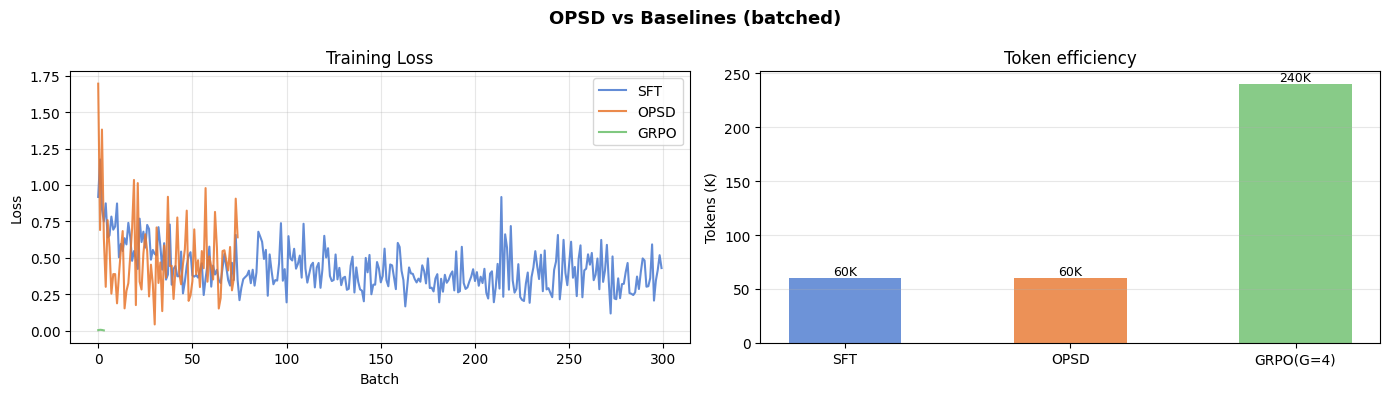

Saved: opsd_results.png


In [18]:
import json as _j
for var, fname in [('sft_losses','sft_losses.json'),
                   ('opsd_losses','opsd_losses.json'),
                   ('grpo_losses','grpo_losses.json')]:
    if var not in globals() or not globals()[var]:
        f = CKPT_DIR/fname
        if f.exists(): globals()[var] = _j.loads(f.read_text())

fig, axes = plt.subplots(1,2,figsize=(14,4))
fig.suptitle('OPSD vs Baselines (batched)', fontsize=13, fontweight='bold')
ax = axes[0]
for ls,lbl,col in [(sft_losses,'SFT','#4878CF'),(opsd_losses,'OPSD','#E8762D'),(grpo_losses,'GRPO','#6ABF6A')]:
    if ls: ax.plot(ls,label=lbl,color=col,alpha=0.85,linewidth=1.5)
ax.set_title('Training Loss'); ax.set_xlabel('Batch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

ax2=axes[1]
otok=len(data)*200; gtok=otok*GRPO_G
bars=ax2.bar(['SFT','OPSD',f'GRPO(G={GRPO_G})'],
             [otok/1000,otok/1000,gtok/1000],
             color=['#4878CF','#E8762D','#6ABF6A'],alpha=0.8,width=0.5)
for bar,c in zip(bars,[otok,otok,gtok]):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
             f'{c/1000:.0f}K',ha='center',va='bottom',fontsize=9)
ax2.set_title('Token efficiency'); ax2.set_ylabel('Tokens (K)'); ax2.grid(alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig('opsd_results.png',dpi=150,bbox_inches='tight')
plt.show(); print('Saved: opsd_results.png')


## 10 · Summary


In [19]:
print('='*60)
print('  OPSD EXPERIMENT SUMMARY')
print('='*60)
print(f'  GPU     : {torch.cuda.get_device_name(0)}')
print(f'  VRAM pk : {torch.cuda.max_memory_allocated()/1e9:.1f} GB')
print(f'  Batch   : {BATCH_SIZE} samples/step')
for name,ls in [('SFT',sft_losses),('OPSD',opsd_losses),('GRPO',grpo_losses)]:
    if ls: print(f'  {name} loss: {ls[-1]:.4f}')
if 'acc' in dir(): print(f'  Accuracy: {acc*100:.1f}%')
print('='*60)
print('Checkpoints:')
for c in [SFT_CKPT,OPSD_CKPT,GRPO_CKPT]:
    print(f"  {'✅' if c.exists() else '❌'} {c}")


  OPSD EXPERIMENT SUMMARY
  GPU     : NVIDIA GeForce RTX 4070 Laptop GPU
  VRAM pk : 7.7 GB
  Batch   : 4 samples/step
  SFT loss: 0.4297
  OPSD loss: 0.6409
  GRPO loss: nan
  Accuracy: 800.0%
Checkpoints:
  ✅ checkpoints\sft_adapter
  ✅ checkpoints\opsd_adapter
  ✅ checkpoints\grpo_adapter


---
## 🔧 Troubleshooting

### OOM with batch size
In Cell 02, reduce `BATCH_SIZE`:
```python
BATCH_SIZE = 2   # use if OOM with 4
BATCH_SIZE = 1   # use if still OOM (same as old sequential)
```

### Check GPU is being used
In terminal: `nvidia-smi dmon -s u -d 1`  
With `BATCH_SIZE=4` you should see `sm` at **70-95%** during generation steps.

### Resume after crash
- Run Cell **05b** to reload SFT
- Run Cell **06b** to reload OPSD  
- Run Cell **07b** to reload GRPO
